# Model validation: Combined effects of 2,4-D and BdJEL423

## Notebook setup

In [54]:
using DrWatson
@quickactivate "."
#using Pkg; Pkg.instantiate()

In [55]:
using Revise

# list directories from which parameters are loaded
const SAVETAG_LARVALFIT = "input/Discoglossus_larvae" 
const SAVETAG_JUVENILEFIT = "input/Discoglossus_juveniles" 
const SAVETAG_TKTDFIT = "Discoglossus_24D_exp2_G"
const SAVETAG_BDFIT = "Discoglossus_BdJEL423_exp2" 
const SAVETAG_CORRECTION_FACTORS = "Discoglossus_24D_exp2_control"

includet(scriptsdir("ModelValidation_Discoglossus_BdJEL423_24D_exp2.jl")) 

## Simulation setup

In [56]:
data = load_data_exp2_all()
p = define_defaultparams_exp2_all()

p.spc.Z = Truncated(Normal(1, 0.1), 0, Inf)

Truncated(Normal{Float64}(μ=1.0, σ=0.1); lower=0.0, upper=Inf)

In [60]:
p.spc.KD .= 0.
p.spc.KD[1,1] = 0.23881284102311123
p.spc.E[1,1] =  0.07107440207209414
p.spc.B[1,1] = 5.9821655043977575

5.9821655043977575

In [61]:
# simulating all treatments
sims = [simulator_exp2_validation(p) for _ in 1:10];

## Visual predictive check

The data indicates a **dominance effect** of BdJEL423 over 2,4-D. <br>
This is something we had already seen in the predictions of combined effects of BdJEL423 and Flupyradifurone. 

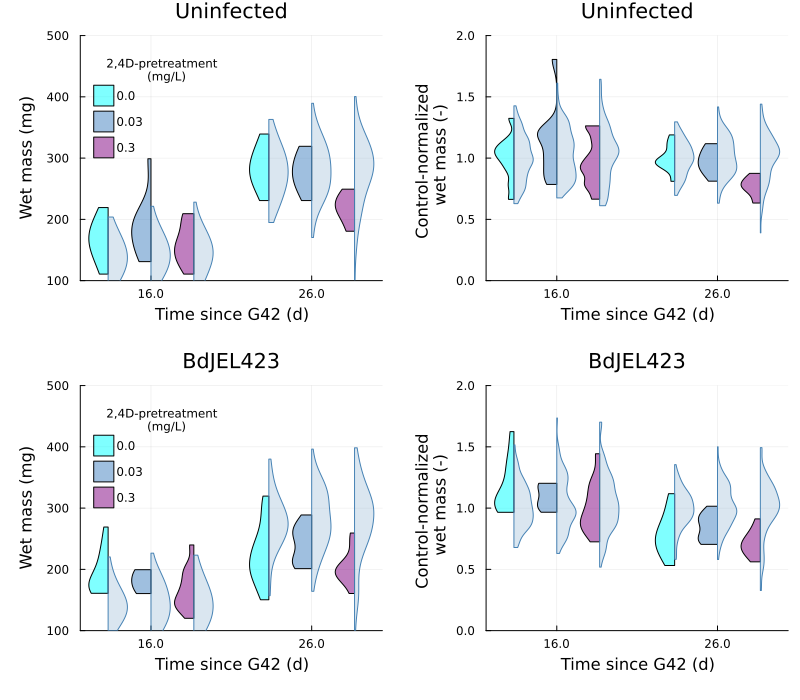

In [62]:
plt = plot_data_exp2_all()
plot_sims_exp2_all!(plt, sims)

#savefig(plot(plt, dpi = 300), plotsdir("ModelValidation_BdJEL423.png"))

plt

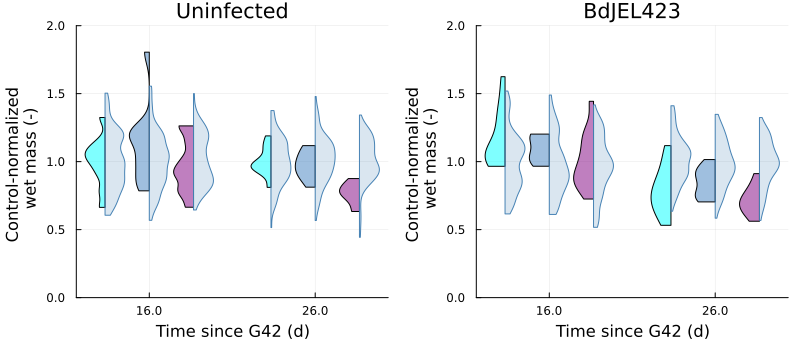

In [9]:
pltsub = plot(
    plot(plt.subplots[2]), plot(plt.subplots[4]), 
    size = (800,350)
    )
savefig(plot(pltsub, dpi = 300), plotsdir("ModelValidation_BdJEL423_subplots.png"))
pltsub

## Quantitative evaluation

In [10]:
# calculating NRMSD - only considering validation treatments
data_valid = @subset(data[:juveniles_aggregated], [t in [5,6] for t in :treatment_id])

eval_df = leftjoin(
    data_valid, 
    EcotoxModelFitting.extract_simkey(sims, :juveniles_aggregated), 
    on = [:t_since_mm, :treatment_id],
    makeunique = true
    ) |> 
    x->DataFrame(
        endpoint = ["y_wetmass_mg", "wetmass_mg"], 
        nrmsd = [
            nrmsd(x.y_wetmass_mg_mean, x.y_wetmass_mg_mean_1),
            nrmsd(x.wetmass_mg_mean, x.wetmass_mg_mean_1)
            ],
        mre = [
            mre(x.y_wetmass_mg_mean, x.y_wetmass_mg_mean_1),
            mre(x.wetmass_mg_mean, x.wetmass_mg_mean_1)
            ]
    )

Row,endpoint,nrmsd,mre
,String,Float64,Float64
1,y_wetmass_mg,0.372278,0.0067601
2,wetmass_mg,0.372278,0.0067601


## Raw simulation output

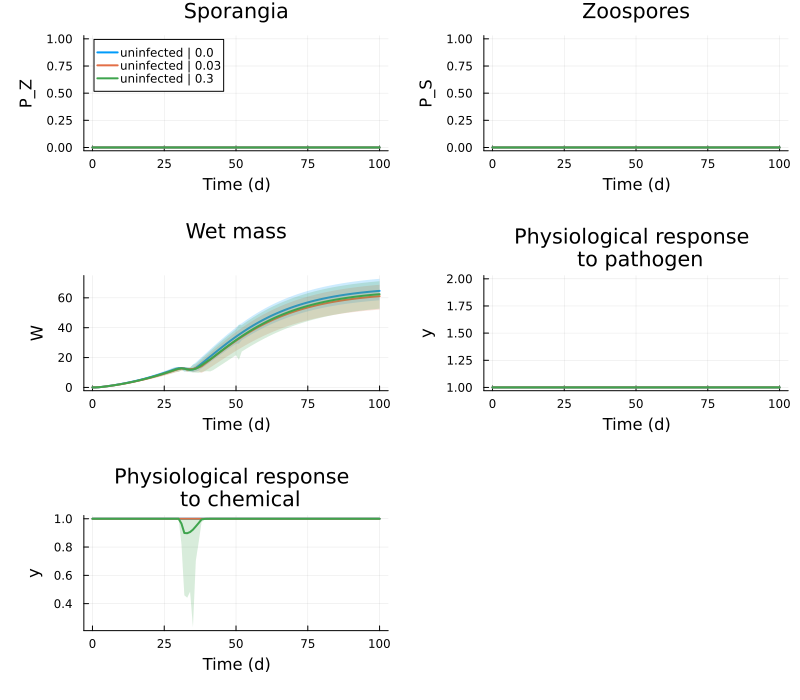

In [74]:
# showing ram simulation output
sim = simulator_exp2_validation(p; return_raw = true); 
df = @subset(sim, [t < 4 for t in :treatment_id])

@df df plot(
    groupedlineplot(title = "Sporangia", ylabel = "P_Z", :t, :P_Z, :treatment_id), 
    groupedlineplot(title = "Zoospores", ylabel = "P_S", :t, :P_S, :treatment_id), 
    groupedlineplot(title = "Wet mass", ylabel = "W", :t, :S .+ :E_mt, :treatment_id), 
    groupedlineplot(title = "Physiological response \n to pathogen", ylabel = "y", :t, :y_jP_1_2, :treatment_id), 
    groupedlineplot(title = "Physiological response \n to chemical", ylabel = "y", :t, :y_j_1_1, :treatment_id), 
    xlabel = "Time (d)", leg = [:topleft false false false false],
    label = hcat([TREATMENT_MAP[id] for id in unique(:treatment_id)]...),
    layout = (3, 2), 
    size = (800,700), 
    bottommargin = 5mm, leftmargin = 5mm, fillalpha = .2, lw = 2
)

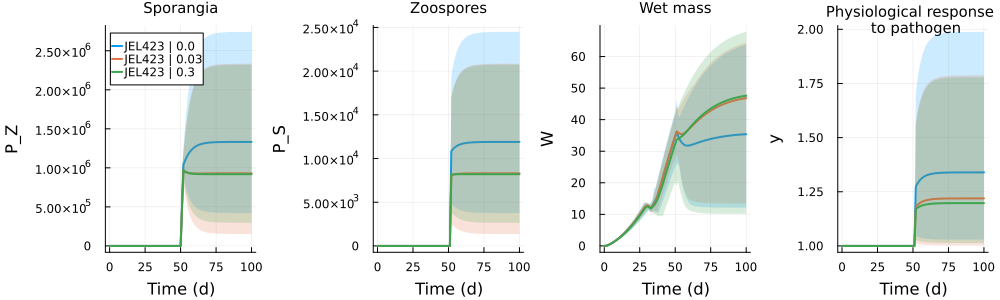

In [78]:
# showing ram simulation output
sim = simulator_exp2_validation(p; return_raw = true); 
df = @subset(sim, [t >= 4 for t in :treatment_id])

@df df plot(
    groupedlineplot(title = "Sporangia", ylabel = "P_Z", :t, :P_Z, :treatment_id), 
    groupedlineplot(title = "Zoospores", ylabel = "P_S", :t, :P_S, :treatment_id), 
    groupedlineplot(title = "Wet mass", ylabel = "W", :t, :S .+ :E_mt, :treatment_id), 
    groupedlineplot(title = "Physiological response \n to pathogen", ylabel = "y", :t, :y_jP_1_2, :treatment_id), 
    xlabel = "Time (d)", leg = [:topleft false false false],
    label = hcat([TREATMENT_MAP[id] for id in unique(:treatment_id)]...),
    layout = (1, 4), 
    size = (1000,300), 
    bottommargin = 5mm, leftmargin = 5mm, fillalpha = .2, lw = 2, 
    titlefontsize = 10
)



In [24]:
p.spc.E_P

4-element view(::Vector{Any}, 89:92) with eltype Any:
    Inf
 19280.316065518626
    Inf
    Inf

In [25]:
p.spc.B_P

4-element view(::Vector{Any}, 93:96) with eltype Any:
 2.0
 2.235336665572955
 2.0
 2.0